<a href="https://colab.research.google.com/github/AtharvaChitnis/PGIT/blob/main/Marketing_Research_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective :

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [110]:
pass # Unzip command disabled as bank-full.csv is assumed to be directly available in /kaggle/input

In [111]:
df = pd.read_csv('/content/bank-full.csv', sep=';')
display(df.describe())

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [112]:
display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [113]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

In [114]:
display(df.shape)

(45211, 17)

The target variable exhibits significant class imbalance, with the no class substantially more frequent than the yes class. Therefore, accuracy alone may not provide a reliable measure of model performance, and metrics such as precision, recall, F1-score, and ROC-AUC should also be considered.

In [115]:
display(df.isnull().sum())

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [116]:
y = df["y"]

In [117]:
X = df.drop("y", axis=1)

In [118]:
print(df['y'].value_counts(normalize=True)*100)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


## Importance of Normalization for Machine Learning Models

Normalization is a crucial data preprocessing step in many machine learning workflows. Its primary goals are to transform numerical features to a common scale, preventing features with larger values from dominating those with smaller values during model training.

Here's why normalization is important:

*   **Prevents dominance by large values**

*   **Improves convergence for gradient-based optimization**

*   **Avoids bias in distance-based algorithms**

*   **Enhances interpretability**

Common normalization techniques include:
*   **Min-Max Scaling**: Scales features to a fixed range, usually 0 to 1.
*   **Standardization (Z-score normalization)**: Scales features to have a mean of 0 and a standard deviation of 1.

In [119]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
Name: count, dtype: int64

poutcome
poutcome
unknown    36959
failure     4901
ot

In [120]:
X = df.drop("y", axis=1)
y = df["y"]

In [121]:
print(X.shape)
print(y.shape)
print(X.head())
print(y.head())

(45211, 16)
(45211,)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome  
0  unknown    5   may       261         1     -1         0  unknown  
1  unknown    5   may       151         1     -1         0  unknown  
2  unknown    5   may        76         1     -1         0  unknown  
3  unknown    5   may        92         1     -1         0  unknown  
4  unknown    5   may       198         1     -1         0  unknown  
0    no
1    no
2    no
3    no
4    no
Name: y, dtype: object


In [122]:
print("Numerical columns:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [123]:
X = X.drop("duration", axis=1)

In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [125]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

y
no     0.883018
yes    0.116982
Name: proportion, dtype: float64
y
no     0.883003
yes    0.116997
Name: proportion, dtype: float64


In [126]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

In [127]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [128]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [129]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]
print(y_prob)

[0.01323245 0.02565882 0.03579249 ... 0.07436168 0.1167111  0.06735449]


In [130]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred, pos_label="yes"))
print("F1:", f1_score(y_test, y_pred, pos_label="yes"))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8932876257879022
Precision: 0.6631578947368421
Recall: 0.1786389413988658
F1: 0.28145941921072226
ROC-AUC: 0.7717487775401183

Classification Report:
              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.66      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.87      9043



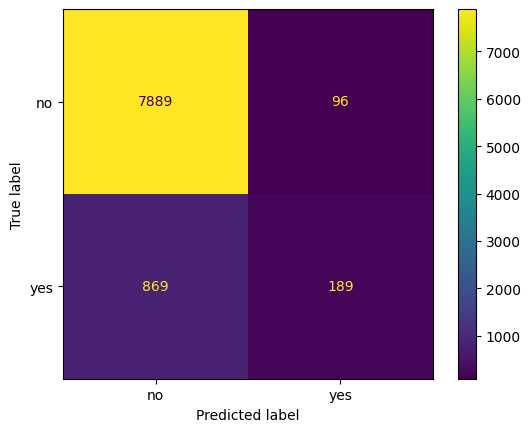

In [131]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [132]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [133]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_dt, pos_label="yes"))
print("F1:", f1_score(y_test, y_pred_dt, pos_label="yes"))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8309189428287073
Precision: 0.2982005141388175
Recall: 0.32892249527410206
F1: 0.31280898876404495
ROC-AUC: 0.6131775907804449

Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.90      0.90      7985
         yes       0.30      0.33      0.31      1058

    accuracy                           0.83      9043
   macro avg       0.60      0.61      0.61      9043
weighted avg       0.84      0.83      0.83      9043



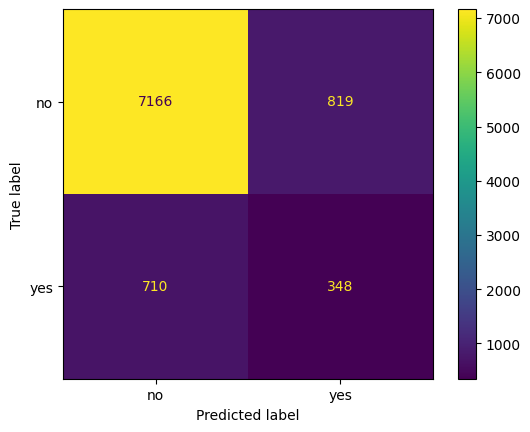

In [134]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt
)

plt.show()

In [135]:
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

              precision    recall  f1-score   support

          no       0.91      0.90      0.90      7985
         yes       0.30      0.33      0.31      1058

    accuracy                           0.83      9043
   macro avg       0.60      0.61      0.61      9043
weighted avg       0.84      0.83      0.83      9043

ROC-AUC: 0.6131775907804449


## Understanding Classification Metrics: Precision, Recall, F1-Score, and Support

When evaluating classification models, especially with imbalanced datasets (like our bank marketing dataset where 'no' is much more frequent than 'yes'), accuracy alone can be misleading. Therefore, we use a set of metrics that provide a more nuanced view of the model's performance.

Let's break down these metrics:

*   **Precision**: Also known as Positive Predictive Value, precision answers the question: "Of all the instances predicted as positive, how many were actually positive?"
    *   **Formula**: `Precision = TP / (TP + FP)`
    *   `TP` (True Positives): Correctly predicted positive instances.
    *   `FP` (False Positives): Incorrectly predicted positive instances (Type I error).
    *   **High precision** indicates a low false positive rate, meaning that when the model predicts 'yes', it is usually correct. This is important when the cost of a false positive is high.

*   **Recall**: Also known as Sensitivity or True Positive Rate, recall answers the question: "Of all the actual positive instances, how many did the model correctly identify?"
    *   **Formula**: `Recall = TP / (TP + FN)`
    *   `FN` (False Negatives): Incorrectly predicted negative instances (Type II error).
    *   **High recall** indicates a low false negative rate, meaning the model is good at finding most of the positive instances. This is important when the cost of a false negative is high.

*   **F1-Score**: The F1-Score is the harmonic mean of Precision and Recall. It provides a single score that balances both precision and recall, making it particularly useful when you need to find a balance between missing positive instances and incorrectly classifying negative instances as positive.
    *   **Formula**: `F1-Score = 2 * (Precision * Recall) / (Precision + Recall)`
    *   A **high F1-Score** suggests the model has good performance on both precision and recall.

*   **Support**: Support simply refers to the number of actual occurrences of each class in the specified dataset (e.g., in `y_test`).
    *   It helps in understanding the distribution of classes and the relevance of other metrics. For instance, if a class has very low support, its precision, recall, or F1-score might be less reliable or harder to optimize.

In our context (bank marketing), 'yes' typically refers to a client subscribing to a term deposit. If the goal is to maximize subscriptions without annoying too many non-interested clients, a balance between precision and recall (or a high F1-score) might be desired. If avoiding missed opportunities (actual subscribers) is paramount, recall would be critical. If avoiding false advertising to non-subscribers is paramount, precision would be critical.

In [136]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [137]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [138]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])

In [139]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [140]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_rf, pos_label="yes"))
print("F1:", f1_score(y_test, y_pred_rf, pos_label="yes"))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.895388698440783
Precision: 0.6372549019607843
Recall: 0.24574669187145556
F1: 0.35470668485675305
ROC-AUC: 0.7887879921355377

Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.98      0.94      7985
         yes       0.64      0.25      0.35      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.61      0.65      9043
weighted avg       0.88      0.90      0.87      9043



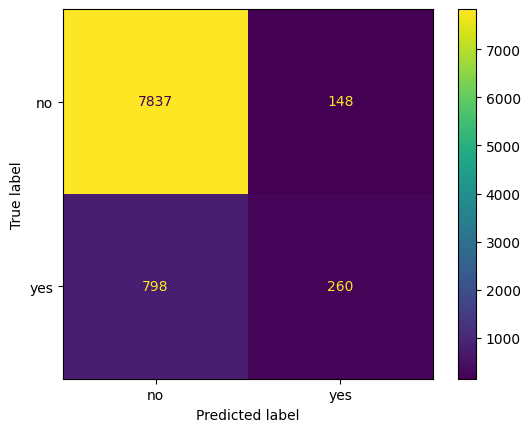

In [141]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.show()

In [142]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

ROC-AUC: 0.7887879921355377


In [143]:
!pip install xgboost

In [144]:
from xgboost import XGBClassifier

In [145]:
y_train_xgb = y_train.map({"no": 0, "yes": 1})
y_test_xgb = y_test.map({"no": 0, "yes": 1})

In [146]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

In [147]:
xgb_model.fit(X_train, y_train_xgb)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model',
                 XGBClassifier(base...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [148]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [149]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))
print("Precision:", precision_score(y_test_xgb, y_pred_xgb))
print("Recall:", recall_score(y_test_xgb, y_pred_xgb))
print("F1:", f1_score(y_test_xgb, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test_xgb, y_prob_xgb))

print("\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_xgb))

Accuracy: 0.8973791883224593
Precision: 0.6633165829145728
Recall: 0.2495274102079395
F1: 0.3626373626373626
ROC-AUC: 0.8072644478718959

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.66      0.25      0.36      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.62      0.65      9043
weighted avg       0.88      0.90      0.88      9043



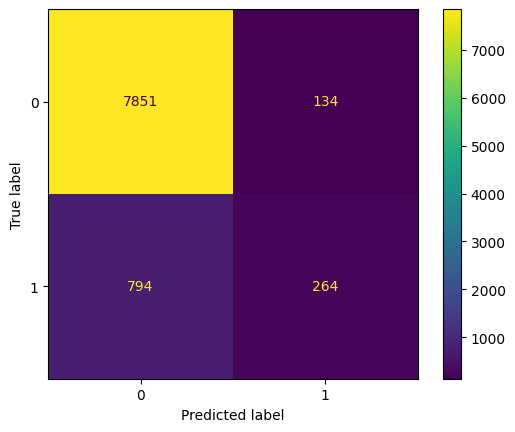

In [150]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_xgb,
    y_pred_xgb
)

plt.show()

In [151]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

ROC-AUC: 0.8072644478718959


### Error Analysis

In [152]:
error_analysis = X_test.copy()

error_analysis["actual"] = y_test_xgb.values
error_analysis["predicted"] = y_pred_xgb
error_analysis["probability"] = y_prob_xgb

error_analysis.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,actual,predicted,probability
1392,40,blue-collar,married,primary,no,640,yes,yes,unknown,8,may,2,-1,0,unknown,0,0,0.020652
7518,44,technician,married,secondary,no,378,yes,no,unknown,30,may,2,-1,0,unknown,0,0,0.028250
12007,31,services,married,secondary,no,356,yes,no,unknown,20,jun,5,-1,0,unknown,0,0,0.051265
5536,36,blue-collar,married,primary,no,655,yes,no,unknown,23,may,4,-1,0,unknown,0,0,0.044439
29816,34,services,single,secondary,no,1921,yes,no,cellular,4,feb,1,-1,0,unknown,0,0,0.111971


In [153]:
false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
]

print("Number of false negatives:", len(false_negatives))
false_negatives.head()

Number of false negatives: 794


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,actual,predicted,probability
41933,31,blue-collar,single,unknown,no,6281,no,no,cellular,22,oct,1,128,3,other,1,0,0.372791
34965,49,management,married,secondary,no,99,yes,no,cellular,6,may,2,343,1,failure,1,0,0.035478
28098,51,admin.,single,tertiary,no,394,no,no,telephone,28,jan,2,-1,0,unknown,1,0,0.039626
42623,66,self-employed,married,tertiary,no,147,no,no,telephone,12,jan,1,-1,0,unknown,1,0,0.192756
16545,40,services,married,secondary,no,471,yes,no,cellular,24,jul,4,-1,0,unknown,1,0,0.065443


In [154]:
false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

print("Number of false positives:", len(false_positives))
false_positives.head()

Number of false positives: 134


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,actual,predicted,probability
43303,42,management,married,tertiary,no,1205,no,no,telephone,15,mar,1,188,2,success,0,1,0.724520
44882,39,admin.,married,tertiary,no,1322,yes,no,cellular,24,sep,3,486,1,other,0,1,0.688396
40775,55,admin.,divorced,secondary,no,1693,no,no,cellular,10,aug,1,102,3,success,0,1,0.566824
40856,37,management,married,tertiary,no,393,yes,no,cellular,12,aug,2,104,2,success,0,1,0.506465
43264,51,admin.,divorced,tertiary,no,66,yes,no,cellular,10,mar,1,478,2,failure,0,1,0.664159


In [155]:
print("Actual YES:", (error_analysis["actual"] == 1).sum())
print("Predicted YES:", (error_analysis["predicted"] == 1).sum())

Actual YES: 1058
Predicted YES: 398


In [156]:
print("Actual YES customers:")
print(
    error_analysis[error_analysis["actual"] == 1]
    .describe()
)

Actual YES customers:
               age       balance          day     campaign        pdays  \
count  1058.000000   1058.000000  1058.000000  1058.000000  1058.000000   
mean     41.893195   1703.848771    14.954631     2.104915    72.036862   
std      13.339782   2797.942203     8.427094     1.759783   118.915318   
min      18.000000  -3058.000000     1.000000     1.000000    -1.000000   
25%      32.000000    202.500000     8.000000     1.000000    -1.000000   
50%      38.000000    703.000000    15.000000     2.000000    -1.000000   
75%      51.000000   2048.000000    21.000000     2.000000   110.750000   
max      93.000000  27696.000000    31.000000    17.000000   792.000000   

          previous  actual    predicted  probability  
count  1058.000000  1058.0  1058.000000  1058.000000  
mean      1.172968     1.0     0.249527     0.311832  
std       2.336690     0.0     0.432944     0.257360  
min       0.000000     1.0     0.000000     0.015346  
25%       0.000000     1.0 

In [157]:
print("False negatives:")
print(
    false_negatives.describe()
)

False negatives:
              age       balance         day    campaign       pdays  \
count  794.000000    794.000000  794.000000  794.000000  794.000000   
mean    41.323678   1607.744332   14.719144    2.254408   49.743073   
std     12.345173   2741.501123    8.402573    1.934165  107.375522   
min     18.000000  -3058.000000    1.000000    1.000000   -1.000000   
25%     32.000000    160.000000    7.000000    1.000000   -1.000000   
50%     38.000000    652.000000   14.000000    2.000000   -1.000000   
75%     50.000000   1980.750000   21.000000    3.000000   -1.000000   
max     83.000000  22867.000000   31.000000   17.000000  749.000000   

         previous  actual  predicted  probability  
count  794.000000   794.0      794.0   794.000000  
mean     0.739295     1.0        0.0     0.184790  
std      2.113141     0.0        0.0     0.136839  
min      0.000000     1.0        0.0     0.015346  
25%      0.000000     1.0        0.0     0.070440  
50%      0.000000     1.0      

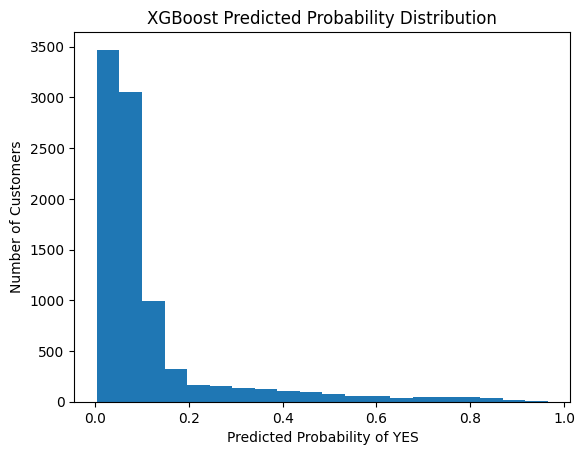

In [158]:
import matplotlib.pyplot as plt

plt.hist(
    y_prob_xgb,
    bins=20
)

plt.xlabel("Predicted Probability of YES")
plt.ylabel("Number of Customers")
plt.title("XGBoost Predicted Probability Distribution")

plt.show()

In [159]:
borderline = error_analysis[
    (error_analysis["probability"] >= 0.4) &
    (error_analysis["probability"] <= 0.6)
]

borderline.sort_values("probability").head(20)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,actual,predicted,probability
40559,20,student,single,unknown,no,829,no,no,cellular,9,jul,2,-1,0,unknown,1,0,0.400122
43499,27,services,single,secondary,no,453,no,no,cellular,19,apr,2,-1,0,unknown,1,0,0.400944
42671,64,housemaid,married,primary,no,768,no,no,cellular,14,jan,1,-1,0,unknown,1,0,0.401459
41213,25,student,single,secondary,no,3090,no,no,cellular,21,aug,1,-1,0,unknown,0,0,0.401481
40299,37,technician,married,unknown,no,189,no,no,cellular,16,jun,2,-1,0,unknown,1,0,0.401581
39803,47,unknown,single,unknown,no,1819,no,no,cellular,1,jun,1,-1,0,unknown,0,0,0.402315
42176,64,entrepreneur,married,tertiary,no,2331,no,no,telephone,9,nov,1,-1,0,unknown,1,0,0.402340
44076,32,student,single,secondary,no,61,no,yes,cellular,5,jul,3,515,7,failure,0,0,0.403273
42053,66,retired,married,tertiary,no,1948,no,no,cellular,29,oct,2,269,2,failure,1,0,0.403586
33740,64,technician,married,tertiary,no,826,no,no,telephone,22,apr,1,-1,0,unknown,0,0,0.404592


In [160]:
threshold = 0.4

y_pred_04 = (y_prob_xgb >= threshold).astype(int)

print(classification_report(
    y_test_xgb,
    y_pred_04
))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.58      0.33      0.42      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.65      0.68      9043
weighted avg       0.88      0.89      0.88      9043



In [161]:
from sklearn.metrics import confusion_matrix

cm_04 = confusion_matrix(y_test_xgb, y_pred_04)

print(cm_04)

[[7734  251]
 [ 713  345]]


In [162]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    predictions = (y_prob_xgb >= threshold).astype(int)

    precision = precision_score(y_test_xgb, predictions)
    recall = recall_score(y_test_xgb, predictions)
    f1 = f1_score(y_test_xgb, predictions)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.1 | Precision: 0.295 | Recall: 0.707 | F1: 0.416
Threshold: 0.2 | Precision: 0.480 | Recall: 0.538 | F1: 0.507
Threshold: 0.3 | Precision: 0.541 | Recall: 0.439 | F1: 0.484
Threshold: 0.4 | Precision: 0.579 | Recall: 0.326 | F1: 0.417
Threshold: 0.5 | Precision: 0.663 | Recall: 0.250 | F1: 0.363
Threshold: 0.6 | Precision: 0.706 | Recall: 0.177 | F1: 0.283
Threshold: 0.7 | Precision: 0.751 | Recall: 0.120 | F1: 0.207


# 14. Class Weighting
## 14.1 Logistic Regression with Class Weighting

In [163]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_weighted = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [164]:
logistic_weighted.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [165]:
y_pred_lrw = logistic_weighted.predict(X_test)
y_prob_lrw = logistic_weighted.predict_proba(X_test)[:, 1]

In [166]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_lrw))
print("Precision:", precision_score(y_test, y_pred_lrw, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_lrw, pos_label="yes"))
print("F1:", f1_score(y_test, y_pred_lrw, pos_label="yes"))
print("ROC-AUC:", roc_auc_score(
    y_test.map({"no": 0, "yes": 1}),
    y_prob_lrw
))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lrw))

Accuracy: 0.7548379962401858
Precision: 0.2662363856393707
Recall: 0.6238185255198487
F1: 0.37319762510602206
ROC-AUC: 0.7722383533397332

Classification Report:
              precision    recall  f1-score   support

          no       0.94      0.77      0.85      7985
         yes       0.27      0.62      0.37      1058

    accuracy                           0.75      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.75      0.79      9043



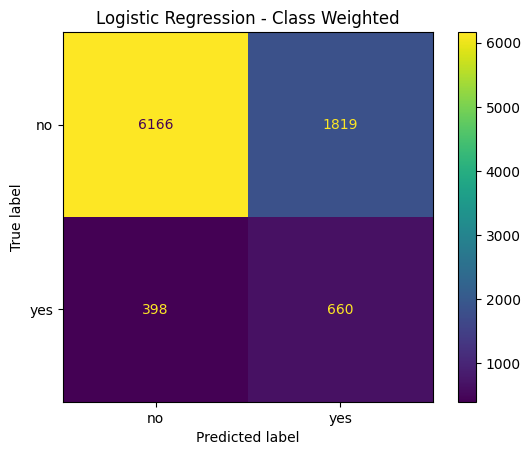

In [167]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lrw
)

plt.title("Logistic Regression - Class Weighted")
plt.show()

In [168]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_weighted = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

In [169]:
decision_tree_weighted.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [170]:
y_pred_dtw = decision_tree_weighted.predict(X_test)
y_prob_dtw = decision_tree_weighted.predict_proba(X_test)[:, 1]

In [171]:
print("Accuracy:", accuracy_score(y_test, y_pred_dtw))
print("Precision:", precision_score(y_test, y_pred_dtw, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_dtw, pos_label="yes"))
print("F1:", f1_score(y_test, y_pred_dtw, pos_label="yes"))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test.map({"no": 0, "yes": 1}),
        y_prob_dtw
    )
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dtw))

Accuracy: 0.840207895609864
Precision: 0.3059177532597793
Recall: 0.2882797731568998
F1: 0.29683698296836986
ROC-AUC: 0.6008086404920379

Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.91      0.91      7985
         yes       0.31      0.29      0.30      1058

    accuracy                           0.84      9043
   macro avg       0.61      0.60      0.60      9043
weighted avg       0.84      0.84      0.84      9043



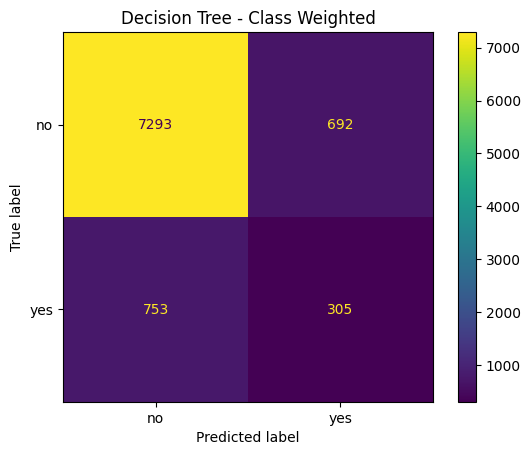

In [172]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dtw
)

plt.title("Decision Tree - Class Weighted")
plt.show()

In [173]:
from sklearn.ensemble import RandomForestClassifier

random_forest_weighted = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [174]:
random_forest_weighted.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [175]:
y_pred_rfw = random_forest_weighted.predict(X_test)
y_prob_rfw = random_forest_weighted.predict_proba(X_test)[:, 1]

In [176]:
print("Accuracy:", accuracy_score(y_test, y_pred_rfw))
print("Precision:", precision_score(y_test, y_pred_rfw, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_rfw, pos_label="yes"))
print("F1:", f1_score(y_test, y_pred_rfw, pos_label="yes"))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test.map({"no": 0, "yes": 1}),
        y_prob_rfw
    )
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rfw))

Accuracy: 0.8932876257879022
Precision: 0.6332378223495702
Recall: 0.20888468809073724
F1: 0.31414356787491116
ROC-AUC: 0.7911418858374575

Classification Report:
              precision    recall  f1-score   support

          no       0.90      0.98      0.94      7985
         yes       0.63      0.21      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043



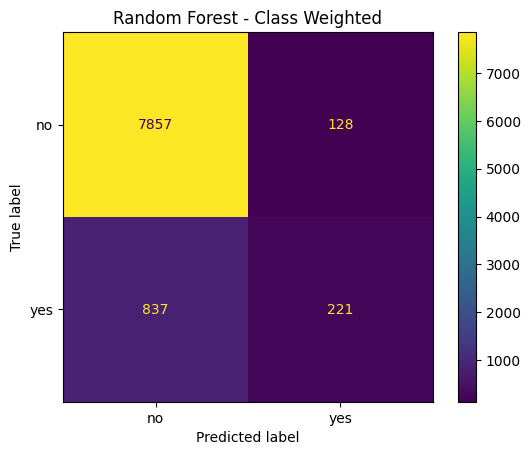

In [177]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rfw
)

plt.title("Random Forest - Class Weighted")
plt.show()

In [178]:
scale_pos_weight

np.float64(7.548622366288493)

In [179]:
negative = (y_train_xgb == 0).sum()
positive = (y_train_xgb == 1).sum()

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("scale_pos_weight:", scale_pos_weight)

Negative: 31937
Positive: 4231
scale_pos_weight: 7.548333727251241


In [180]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_weighted = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ))
])

In [181]:
xgb_weighted.fit(X_train, y_train_xgb)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model',
                 XGBClassifier(base...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [182]:
y_pred_xgbw = xgb_weighted.predict(X_test)
y_prob_xgbw = xgb_weighted.predict_proba(X_test)[:, 1]

In [183]:
print("Accuracy:", accuracy_score(y_test_xgb, y_pred_xgbw))
print("Precision:", precision_score(y_test_xgb, y_pred_xgbw))
print("Recall:", recall_score(y_test_xgb, y_pred_xgbw))
print("F1:", f1_score(y_test_xgb, y_pred_xgbw))
print("ROC-AUC:", roc_auc_score(y_test_xgb, y_prob_xgbw))

print("\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_xgbw))

Accuracy: 0.825389804268495
Precision: 0.3600214938205266
Recall: 0.6332703213610587
F1: 0.4590613223706749
ROC-AUC: 0.8028563717651125

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7985
           1       0.36      0.63      0.46      1058

    accuracy                           0.83      9043
   macro avg       0.65      0.74      0.68      9043
weighted avg       0.88      0.83      0.84      9043



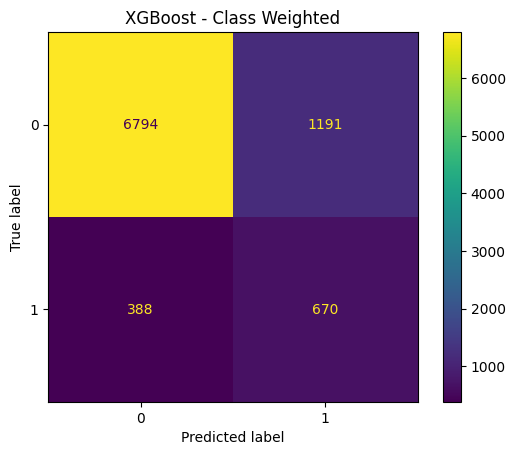

In [184]:
ConfusionMatrixDisplay.from_predictions(
    y_test_xgb,
    y_pred_xgbw
)

plt.title("XGBoost - Class Weighted")
plt.show()

In [185]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    predictions = (y_prob_xgbw >= threshold).astype(int)

    precision = precision_score(y_test_xgb, predictions)
    recall = recall_score(y_test_xgb, predictions)
    f1 = f1_score(y_test_xgb, predictions)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.1 | Precision: 0.120 | Recall: 0.996 | F1: 0.215
Threshold: 0.2 | Precision: 0.140 | Recall: 0.952 | F1: 0.244
Threshold: 0.3 | Precision: 0.182 | Recall: 0.852 | F1: 0.300
Threshold: 0.4 | Precision: 0.253 | Recall: 0.747 | F1: 0.378
Threshold: 0.5 | Precision: 0.360 | Recall: 0.633 | F1: 0.459
Threshold: 0.6 | Precision: 0.463 | Recall: 0.532 | F1: 0.495
Threshold: 0.7 | Precision: 0.521 | Recall: 0.448 | F1: 0.482


In [186]:
import numpy as np

thresholds = np.arange(0.05, 0.96, 0.01)

results = []

for threshold in thresholds:
    predictions = (y_prob_xgbw >= threshold).astype(int)

    precision = precision_score(y_test_xgb, predictions)
    recall = recall_score(y_test_xgb, predictions)
    f1 = f1_score(y_test_xgb, predictions)

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results = pd.DataFrame(results)

best_threshold = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print(best_threshold)

threshold    0.610000
precision    0.471088
recall       0.523629
f1           0.495971
Name: 56, dtype: float64


## I developed a cost-sensitive marketing-response prediction system that selects customers and optimizes the classification threshold based on expected campaign profitability.